# Time Series Analysis for Apple

In this project, we will perform a time series analysis on Apple Inc. data.

<img src='https://www.marktechpost.com/wp-content/uploads/2023/02/stock-market-chart-virtual-screen-with-woman-s-hand-digital-remix-scaled.jpg' width='750'>

### Libraries

In [1]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
import plotly.express as px
import numpy as np

### EDA

In [3]:
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=720)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2
df=yf.download('AAPL',start=start_date, end=end_date,progress=False)

In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-09-05,220.535187,223.609461,219.682321,219.791409,36615400
2024-09-06,218.988129,223.371459,217.946836,222.092153,48423000
2024-09-09,219.077393,219.434407,214.912238,218.988143,67180000
2024-09-10,218.284012,219.642642,214.932047,217.103881,51591000
2024-09-11,220.812866,221.239292,216.082433,219.622824,44587100


In [5]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-08-19,316.829987,319.279999,309.600006,310.140015,50505600
2026-08-20,311.299988,320.279999,310.649994,317.459991,40959200
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800


In [6]:
df.shape

(494, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 494 entries, 2024-09-05 to 2026-08-25
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   494 non-null    float64
 1   (High, AAPL)    494 non-null    float64
 2   (Low, AAPL)     494 non-null    float64
 3   (Open, AAPL)    494 non-null    float64
 4   (Volume, AAPL)  494 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.2 KB


In [9]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,494.000000,494.000000,494.000000,494.000000,4.940000e+02
mean,248.256997,250.749494,245.512393,247.963458,5.193554e+07
std,34.463438,34.653388,34.186494,34.373516,2.552133e+07
min,171.365967,189.176417,168.175599,170.898835,1.791060e+07
25%,222.614487,224.295411,220.226404,222.490752,3.942262e+07
50%,245.559616,247.416307,243.492597,245.704624,4.610810e+07
75%,270.533119,273.135170,267.619745,270.276813,5.483158e+07
max,339.786926,344.273097,337.059318,339.736982,3.186799e+08


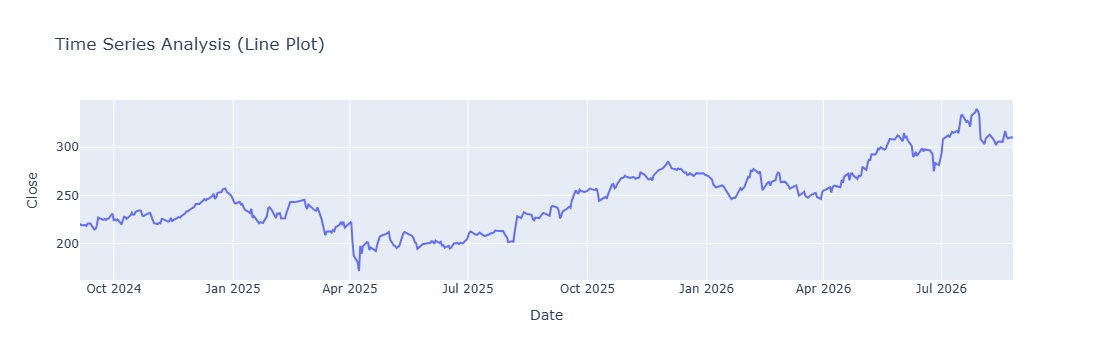

In [18]:
df.columns = df.columns.get_level_values(0)
import plotly.express as px
figure = px.line(df, x = df.index, y = "Close", title = "Time Series Analysis (Line Plot)")
figure.show()

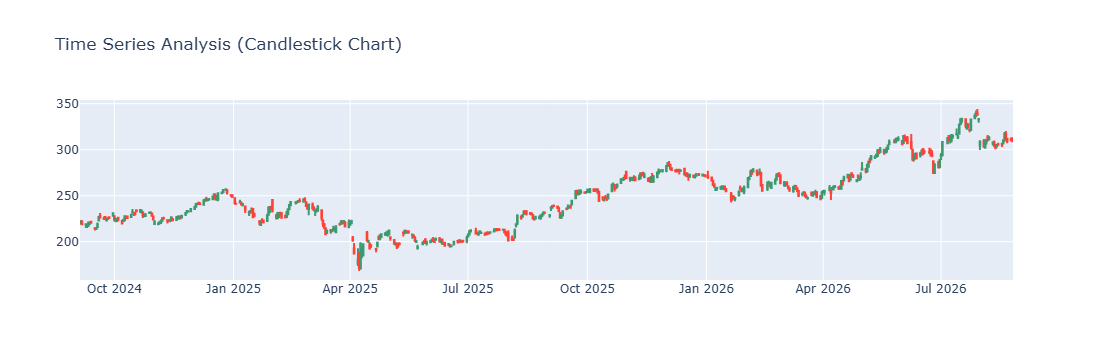

In [21]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x = data.index,open = df["Open"], high = df["High"],low = df["Low"], close = df["Close"])])
figure.update_layout(title = "Time Series Analysis (Candlestick Chart)", xaxis_rangeslider_visible = False)
figure.show()

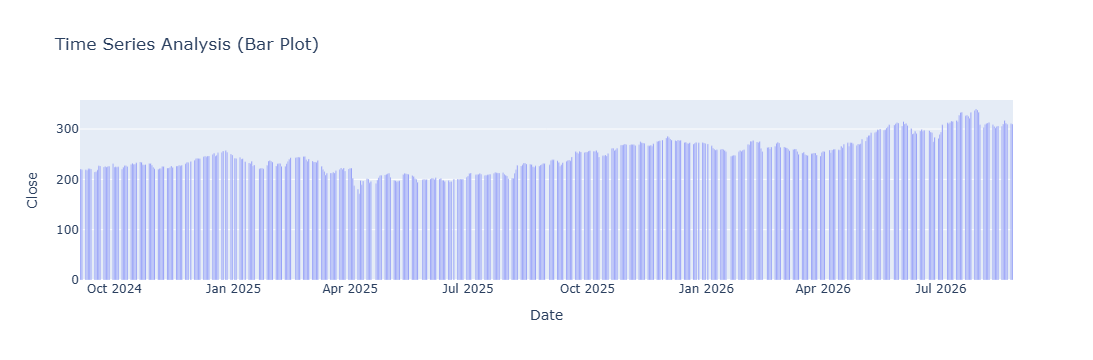

In [22]:
figure = px.bar(df, x = df.index, y = "Close", title = "Time Series Analysis (Bar Plot)" )
figure.show()

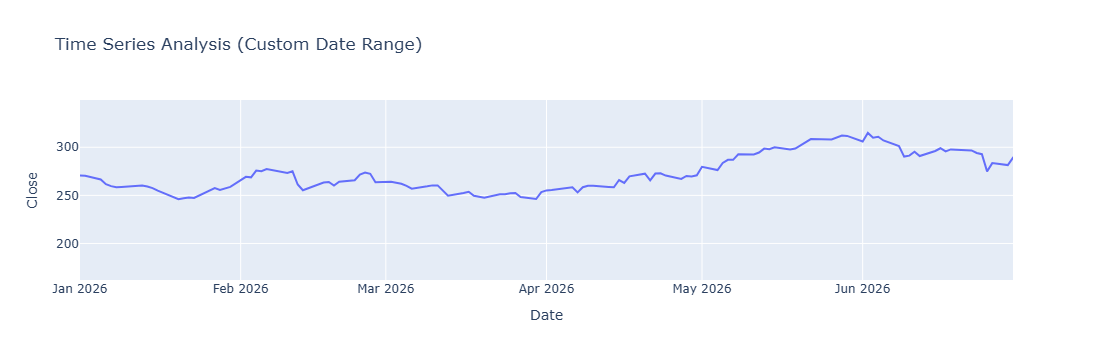

In [23]:
figure = px.line(df, x = df.index, y='Close',range_x = ['2026-01-01','2026-06-30'], title = "Time Series Analysis (Custom Date Range)")
figure.show()

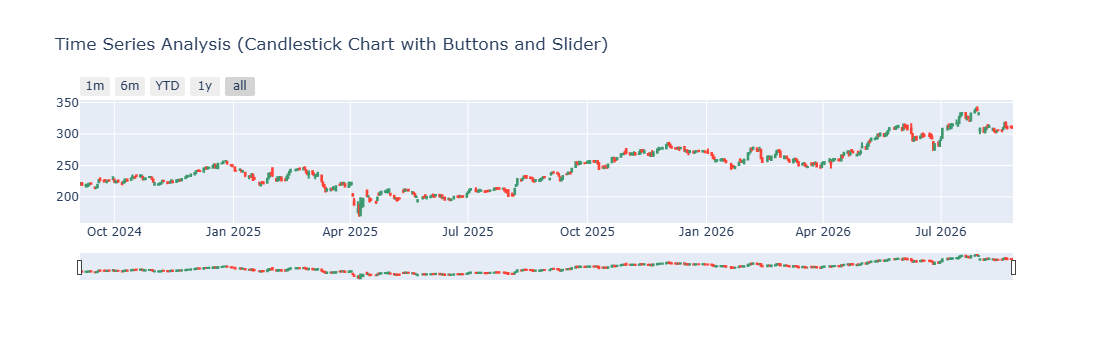

In [26]:
figure = go.Figure(data = [go.Candlestick(x = data.index,
                                        open = df["Open"], 
                                        high = df["High"],
                                        low = df["Low"], 
                                        close = df["Close"])])
figure.update_layout(title = "Time Series Analysis (Candlestick Chart with Buttons and Slider)")
figure.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict(
        buttons = list([
            dict(count = 1, label = "1m", step = "month", stepmode = "backward"),
            dict(count = 6, label = "6m", step = "month", stepmode = "backward"),
            dict(count = 1, label = "YTD", step = "year", stepmode = "todate"),
            dict(count = 1, label = "1y", step = "year", stepmode = "backward"),
            dict(step = "all")
        ])
    )
)
figure.show()

In [28]:
model=sm.tsa.statespace.SARIMAX(df['Close'])
result=model.fit()

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.



In [29]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  494
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1428.506
Date:                Wed, 26 Aug 2026   AIC                           2861.013
Time:                        21:52:46   BIC                           2869.418
Sample:                             0   HQIC                          2864.313
                                - 494                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.001   1786.920      0.000       0.999       1.001
sigma2        18.7064      0.590     31.730      0.000      17.551      19.862
===================================================================================
Ljung-Box (L1) (Q):                   1.97   Jarque-Bera (JB):               827.00
Prob(Q):                              0.16   Prob(JB):                         0.00
Heteroskedasticity (H):               1.15   Skew:                            -0.28
Prob(H) (two-sided):                  0.38   Kurtosis:                         9.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

According to the results of the SARIMAX(1, 0, 0) model trained on 494 observations, the AR(1) coefficient was calculated as $0.9999$ and found to be statistically significant ($p = 0.000$). The Ljung-Box test ($Prob(Q) = 0.16 > 0.05$) and the Heteroskedasticity test ($Prob(H) = 0.38 > 0.05$) indicate that the residuals exhibit white noise properties and that the model successfully captures the autocorrelation structure. However, the Jarque-Bera test ($Prob(JB) = 0.00 < 0.05$) alongside a high kurtosis value ($Kurtosis = 9.31$) shows that the model residuals do not follow a normal distribution.